In [1]:
import pandas as pd
import sqlalchemy
import matplotlib.pyplot as plt
import seaborn as sns
from adjustText import adjust_text
from sklearn import cluster

In [2]:
with open("partidos.sql", "r") as open_file:
    query = open_file.read()

engine = sqlalchemy.create_engine("sqlite:///../data/database.db")

df = pd.read_sql_query(query, engine)
df.head()

,SG_PARTIDO,NM_PARTIDO,SG_UF,txGenFeminino,totalGenFeminino,txCorRacaPreta,totalCorRacaPreta,txCorRacaPretaParda,totalCorRacaPretaParda,txCorRacaNaoBranca,totalCorRacaNaoBranca,totalCandidaturas
0,UP,UNIDADE POPULAR,BR,0.531532,59,0.324324,36,0.549550,61,0.558559,62,111
1,UP,UNIDADE POPULAR,AL,0.833333,5,0.166667,1,0.333333,2,0.500000,3,6
2,UP,UNIDADE POPULAR,BA,0.666667,4,0.500000,3,0.833333,5,0.833333,5,6
3,UP,UNIDADE POPULAR,CE,0.500000,2,0.250000,1,0.250000,1,0.250000,1,4
4,UP,UNIDADE POPULAR,GO,0.500000,2,0.000000,0,0.250000,1,0.250000,1,4


In [3]:
txGenFeminino = df["totalGenFeminino"].sum() / df["totalCandidaturas"].sum()
txCorRacaPreta = df["totalCorRacaPreta"].sum() / df["totalCandidaturas"].sum()
txCorRacaNaoBranca = df["totalCorRacaNaoBranca"].sum() / df["totalCandidaturas"].sum()
txCorRacaPretaParda = df["totalCorRacaPretaParda"].sum() / df["totalCandidaturas"].sum()

Looks like you are using a tranform that doesn't support FancyArrowPatch, using ax.annotate instead. The arrows might strike through texts. Increasing shrinkA in arrowprops might help.


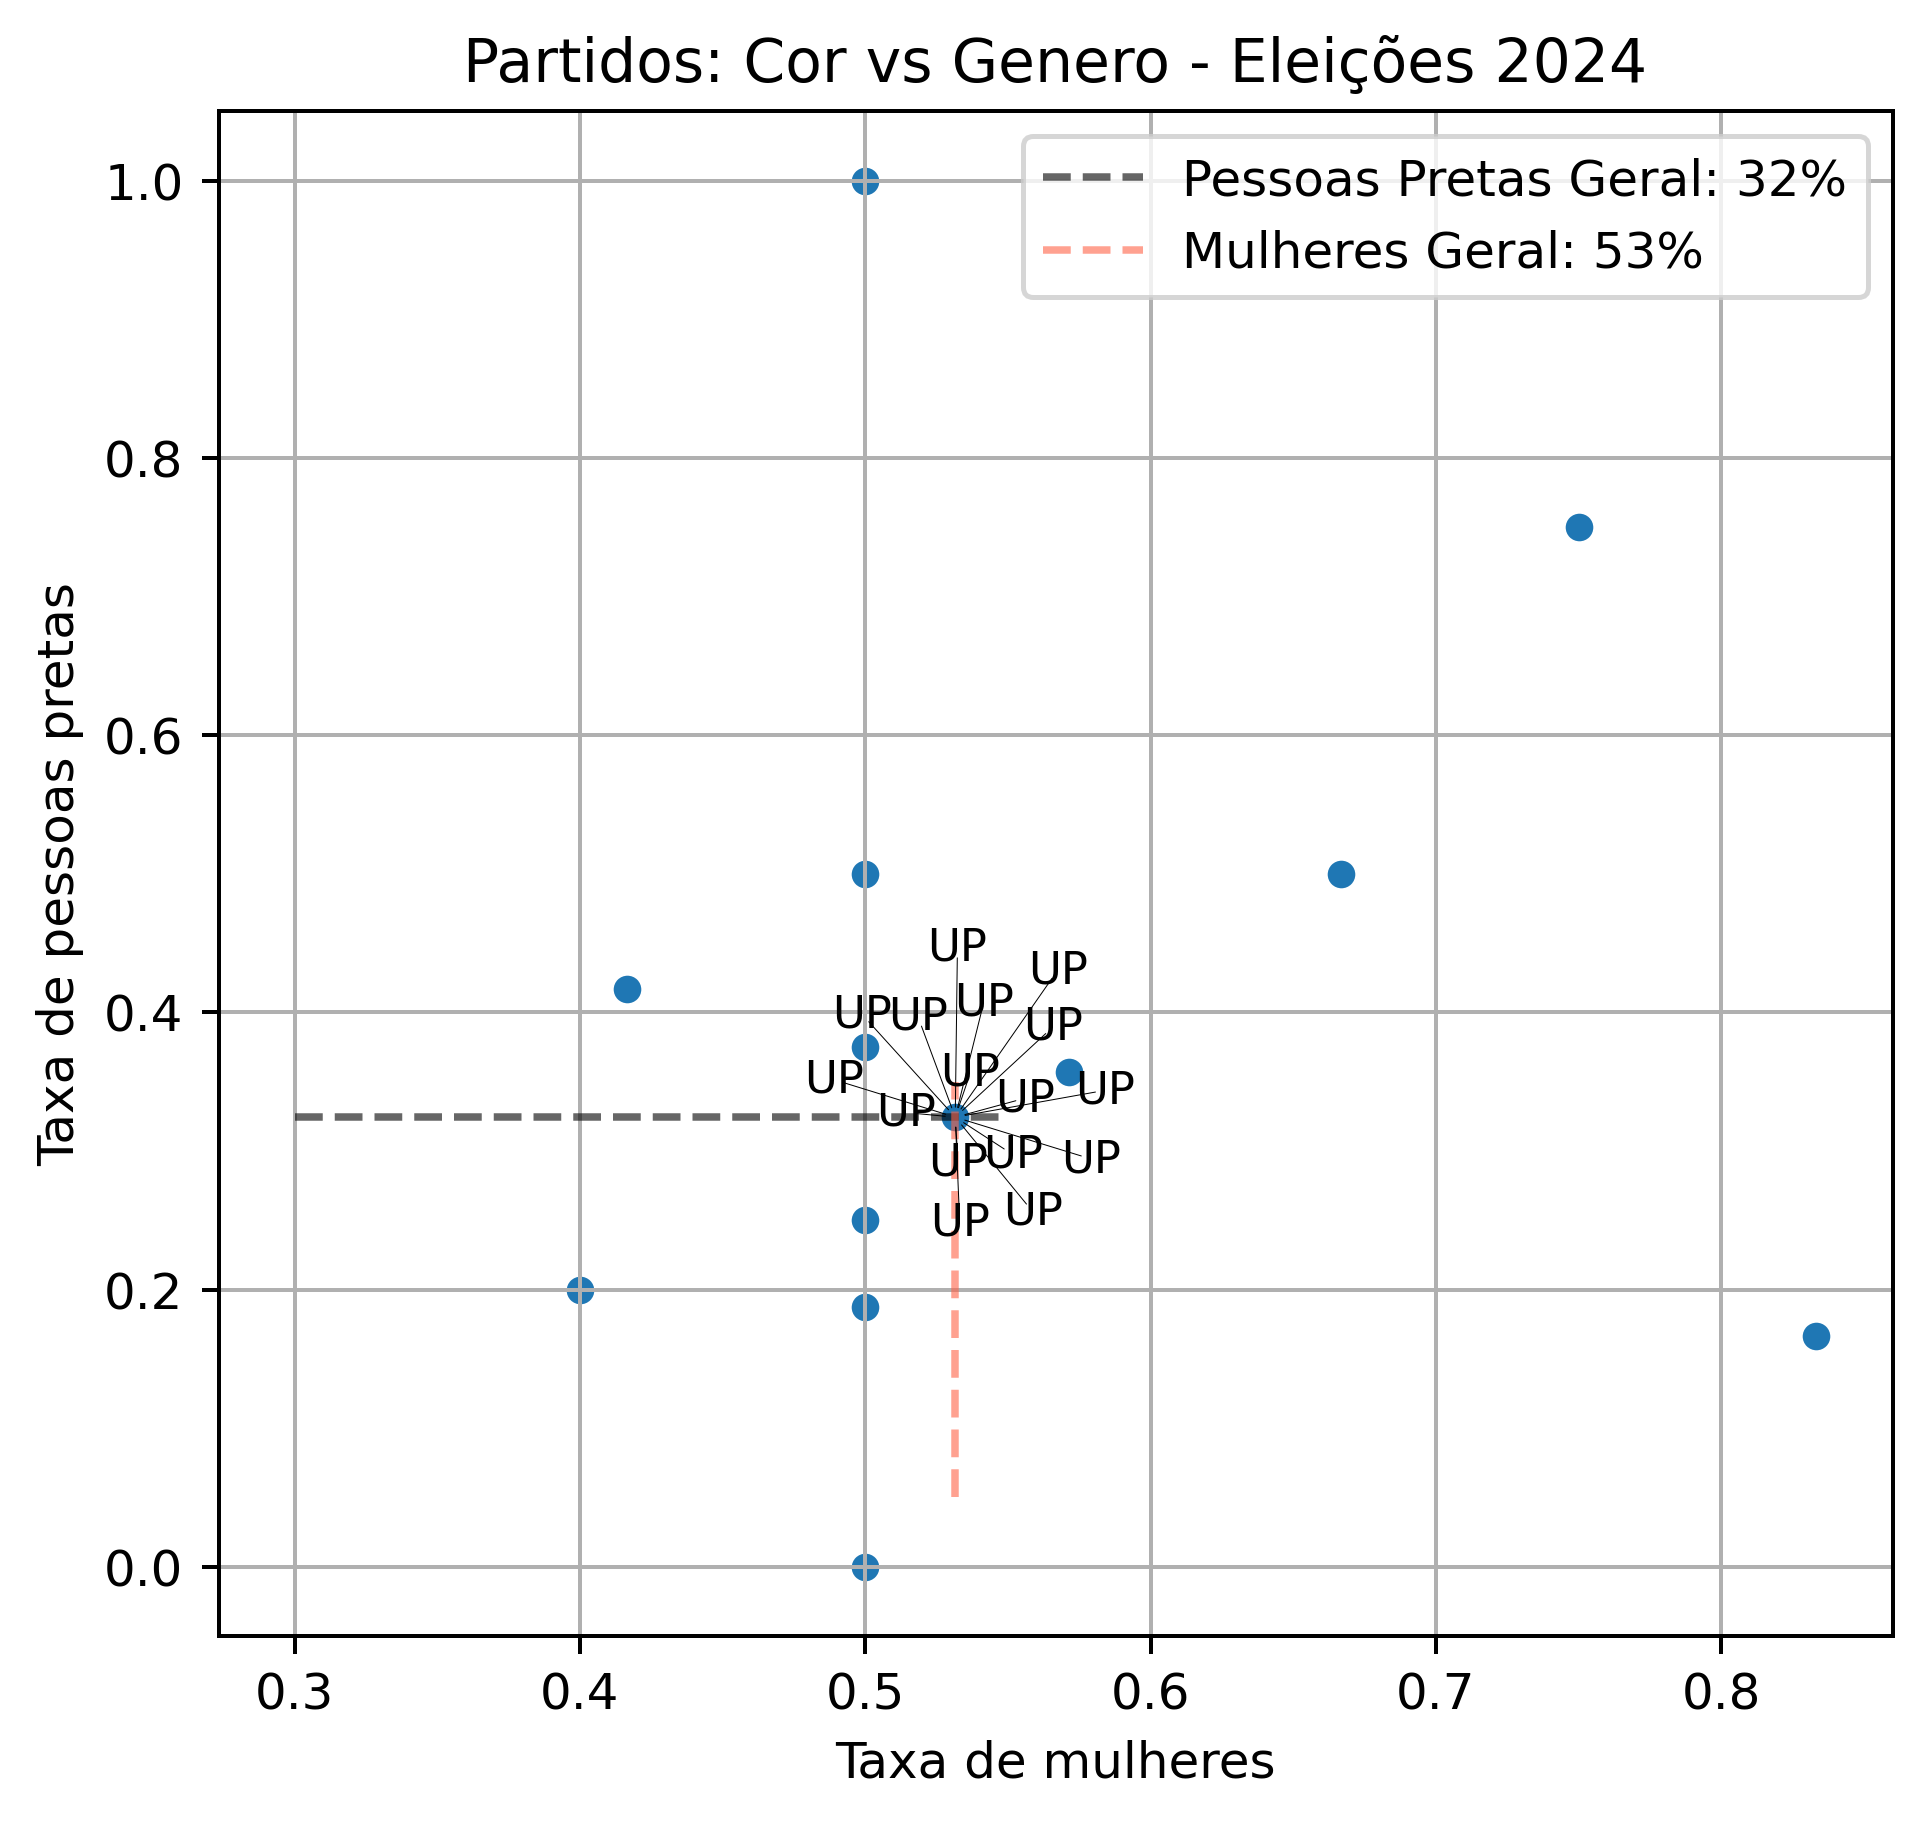

In [ ]:
plt.figure(dpi=360, figsize=(6,5.5))

sns.scatterplot(data=df, 
                x='txGenFemininoBR', 
                y='txCorRacaPretaBR')

texts = []
for i in df['SG_PARTIDO']:
    data = df[df['SG_PARTIDO']==i]
    x = data['txGenFemininoBR'].values[0]
    y = data['txCorRacaPretaBR'].values[0]
    texts.append(plt.text(x, y, i, fontsize=9))

adjust_text(texts, force_poins=0.0002,
            force_text=0.4,
            expand_points=(0.5, 0.75), expand_text=(0.5, 0.75),
            arrowprops=dict(arrowstyle="-", color='black', lw=0.2),
            pull_threshold=1000,)

plt.grid(True)
plt.title("Partidos: Cor vs Genero - Eleições 2024")
plt.xlabel("Taxa de mulheres")
plt.ylabel("Taxa de pessoas pretas")

plt.hlines(y=txCorRacaPreta, xmin=0.3, xmax=0.55, colors="black", alpha=0.6, linestyles="--", label=f"Pessoas Pretas Geral: {100*txCorRacaPreta:.0f}%")
plt.vlines(x=txGenFeminino, ymin=0.05, ymax=0.35, colors="tomato", alpha=0.6, linestyles="--", label=f"Mulheres Geral: {100*txGenFeminino:.0f}%")


plt.legend()

In [ ]:
plt.figure(dpi=360, figsize=(6,5.5))

sns.scatterplot(data=df, 
                x='txGenFemininoBR', 
                y='txCorRacaPretaBR',
                size="totalCandidaturas",
                sizes=(5,200),
                hue="clusterBR",
                palette='viridis',
                )

texts = []
for i in df['SG_PARTIDO']:
    data = df[df['SG_PARTIDO']==i]
    x = data['txGenFemininoBR'].values[0]
    y = data['txCorRacaPretaBR'].values[0]
    texts.append(plt.text(x, y, i, fontsize=9))

adjust_text(texts, force_poins=0.0002,
            force_text=0.4,
            expand_points=(0.5, 0.75), expand_text=(0.5, 0.75),
            arrowprops=dict(arrowstyle="-", color='black', lw=0.2),
            pull_threshold=1000,)

plt.grid(True)
plt.title("Partidos: Cor vs Genero - Eleições 2024")
plt.xlabel("Taxa de mulheres")
plt.ylabel("Taxa de pessoas pretas")

plt.hlines(y=txCorRacaPreta, xmin=0.3, xmax=0.55, colors="black", alpha=0.6, linestyles="--", label=f"Pessoas Pretas Geral: {100*txCorRacaPreta:.0f}%")
plt.vlines(x=txGenFeminino, ymin=0.05, ymax=0.35, colors="tomato", alpha=0.6, linestyles="--", label=f"Mulheres Geral: {100*txGenFeminino:.0f}%")

handles, labels = plt.gca().get_legend_handles_labels()
handles = handles[12:]
labels = labels[12:]

plt.legend(handles=handles, labels=labels)

ValueError: Could not interpret value `clusterBR` for `hue`. An entry with this name does not appear in `data`.

<Figure size 2160x1980 with 0 Axes>

In [16]:
X = df[['txGenFemininoBR', 'txCorRacaPretaBR']]
model = cluster.KMeans(n_clusters=6)
model.fit(X)

df["clusterBR"] = model.labels_

plt.figure(dpi=360, figsize=(6,5.5))

sns.scatterplot(data=df, 
                x='txGenFemininoBR', 
                y='txCorRacaPretaBR',
                #size="totalCandidaturas",
                #sizes=(5,200),
                hue="clusterBR",
                palette='viridis',
                )

texts = []
for i in df['SG_PARTIDO']:
    data = df[df['SG_PARTIDO']==i]
    x = data['txGenFemininoBR'].values[0]
    y = data['txCorRacaPretaBR'].values[0]
    texts.append(plt.text(x, y, i, fontsize=9))

adjust_text(texts, force_poins=0.0002,
            force_text=0.4,
            expand_points=(0.5, 0.75), expand_text=(0.5, 0.75),
            arrowprops=dict(arrowstyle="-", color='black', lw=0.2),
            pull_threshold=1000,)

plt.grid(True)
plt.title("Partidos: Cor vs Genero - Eleições 2024")
plt.xlabel("Taxa de mulheres")
plt.ylabel("Taxa de pessoas pretas")

plt.hlines(y=txCorRacaPreta, xmin=0.3, xmax=0.55, colors="black", alpha=0.6, linestyles="--", label=f"Pessoas Pretas Geral: {100*txCorRacaPreta:.0f}%")
plt.vlines(x=txGenFeminino, ymin=0.05, ymax=0.35, colors="tomato", alpha=0.6, linestyles="--", label=f"Mulheres Geral: {100*txGenFeminino:.0f}%")

handles, labels = plt.gca().get_legend_handles_labels()
handles = handles[6:]
labels = labels[6:]

plt.legend(handles=handles, labels=labels)

KeyError: "None of [Index(['txGenFemininoBR', 'txCorRacaPretaBR'], dtype='str')] are in the [columns]"

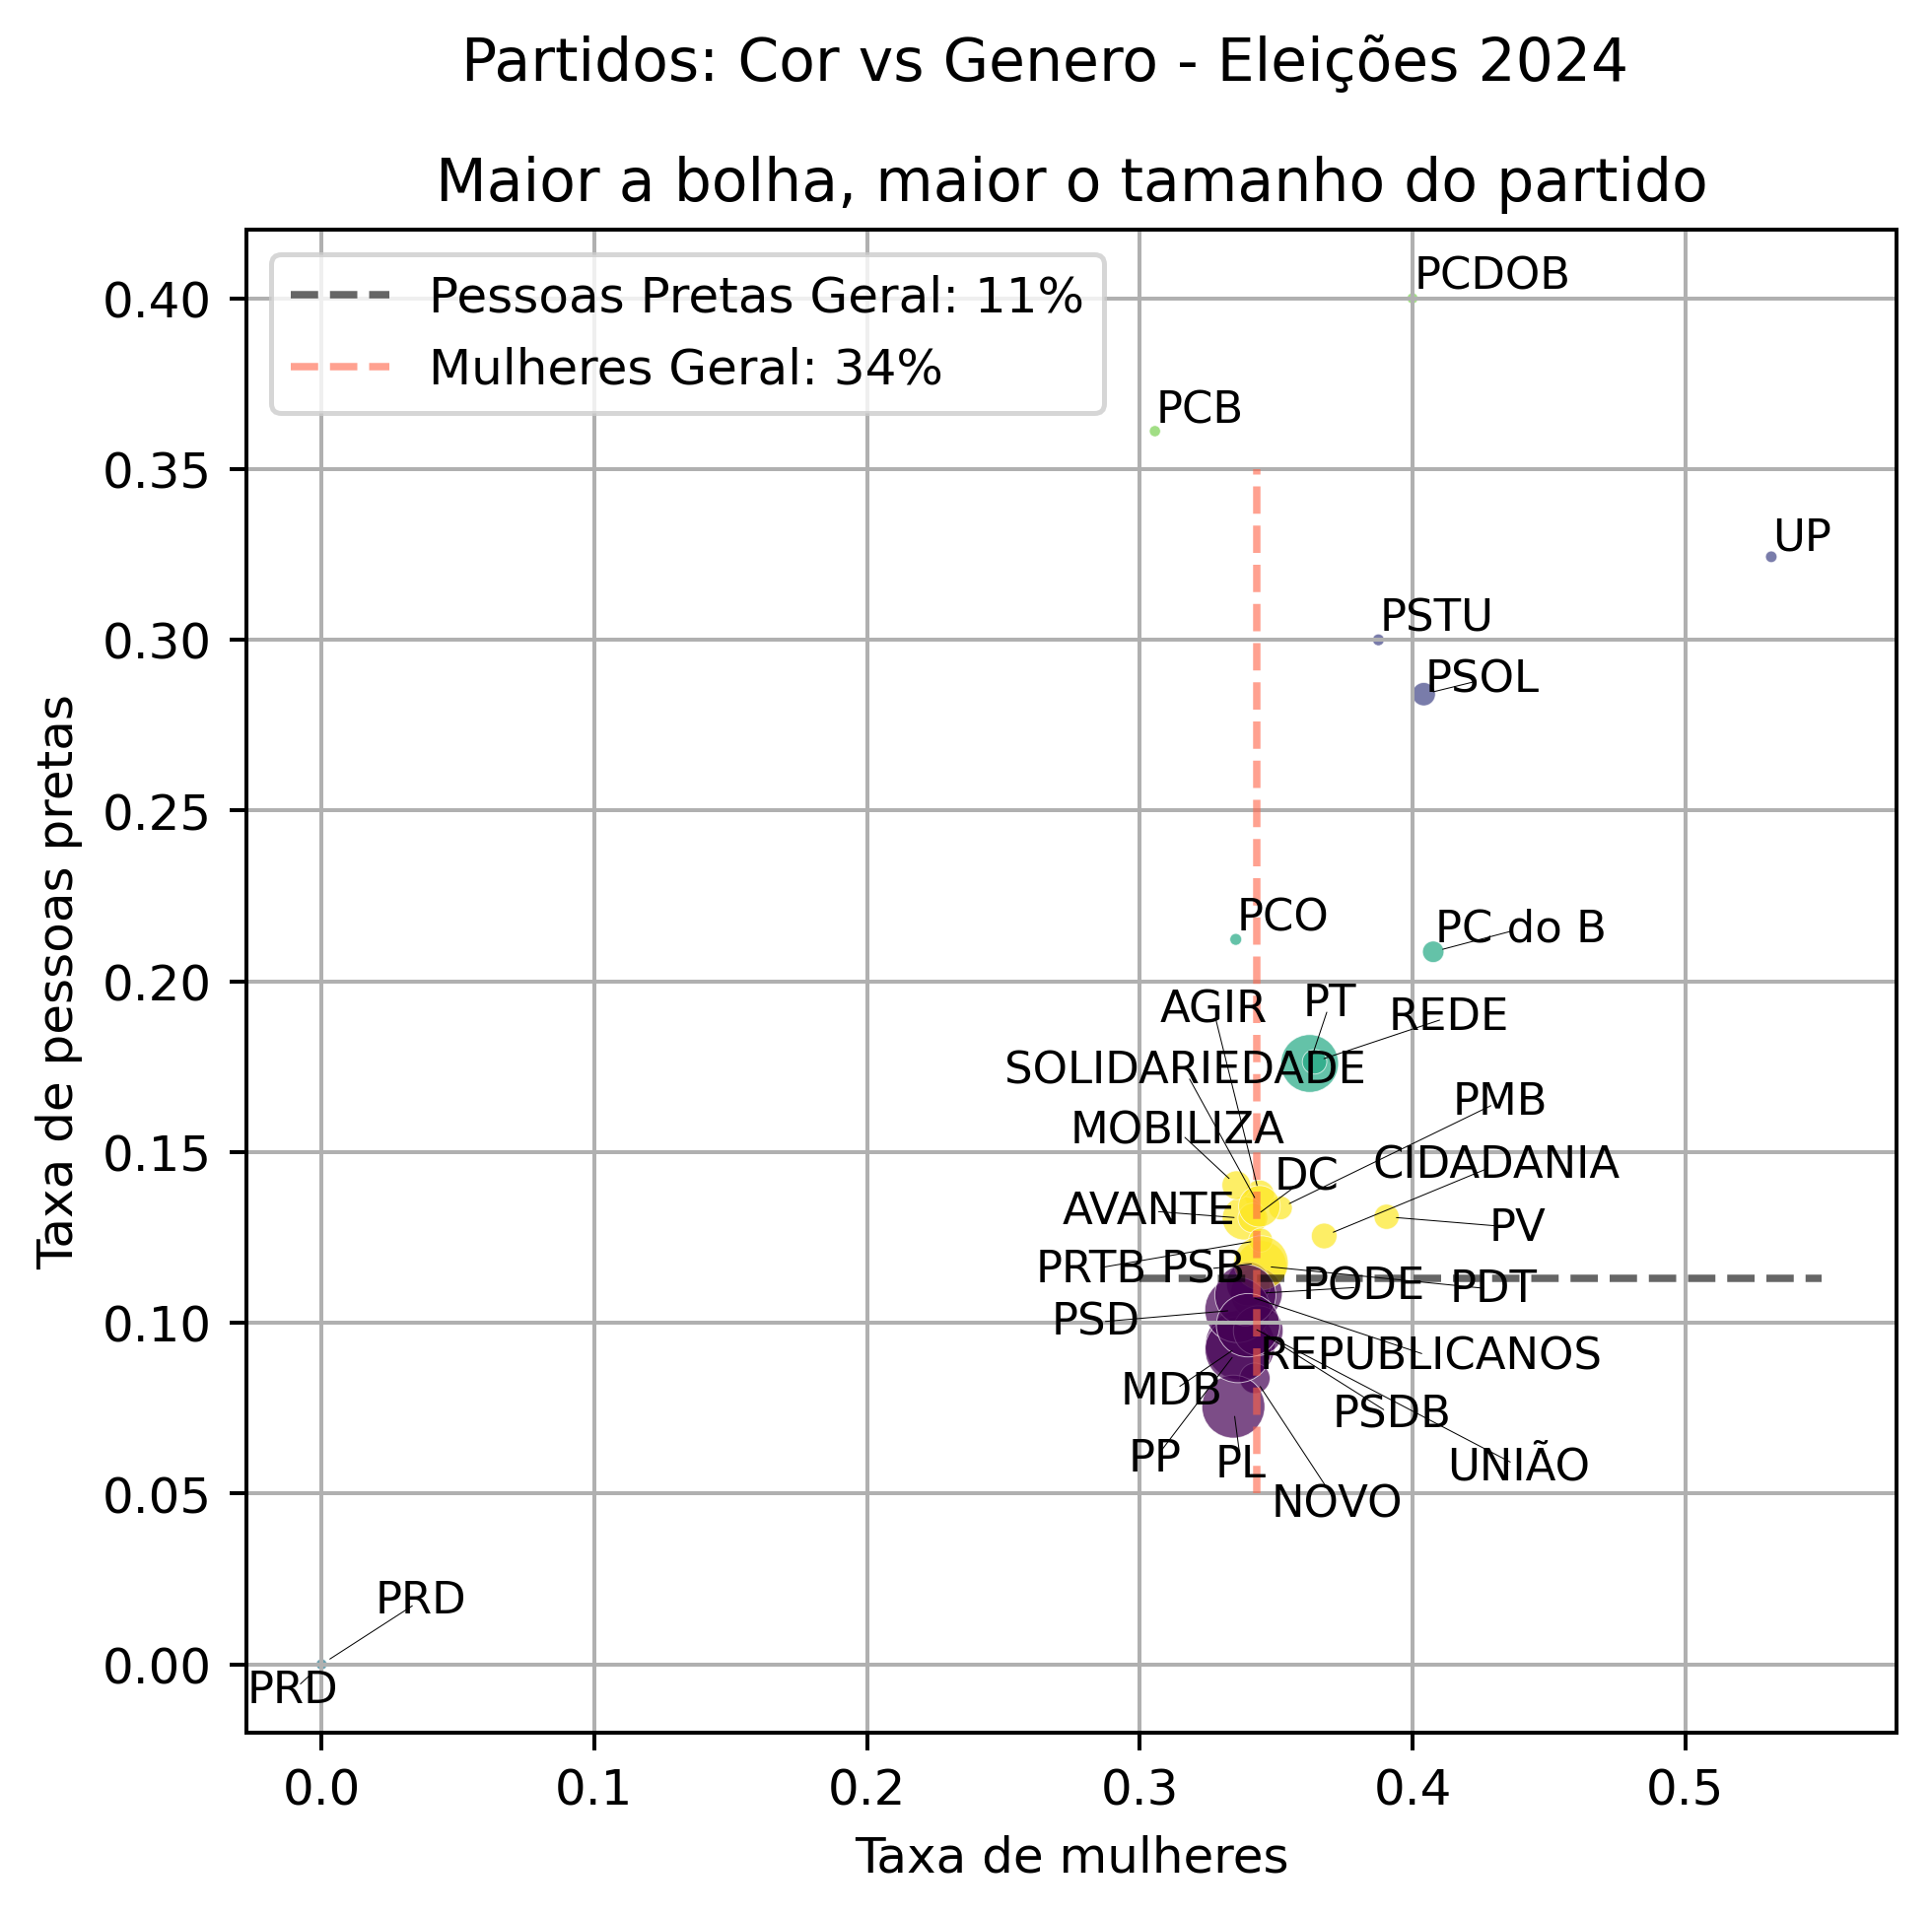

In [34]:
plt.figure(dpi=360, figsize=(6,5.5))

sns.scatterplot(data=df, 
                x='txGenFemininoBR', 
                y='txCorRacaPretaBR',
                size="totalCandidaturas",
                sizes=(5,200),
                hue="clusterBR",
                palette='viridis',
                alpha=0.6
                )

texts = []
for i in df['SG_PARTIDO']:
    data = df[df['SG_PARTIDO']==i]
    x = data['txGenFemininoBR'].values[0]
    y = data['txCorRacaPretaBR'].values[0]
    texts.append(plt.text(x, y, i, fontsize=9))

adjust_text(texts, force_poins=0.0002,
            force_text=0.4,
            expand_points=(0.5, 0.75), expand_text=(0.5, 0.75),
            arrowprops=dict(arrowstyle="-", color='black', lw=0.2),
            pull_threshold=1000,)

plt.grid(True)
plt.suptitle("Partidos: Cor vs Genero - Eleições 2024")
plt.title("Maior a bolha, maior o tamanho do partido")
plt.xlabel("Taxa de mulheres")
plt.ylabel("Taxa de pessoas pretas")

plt.hlines(y=txCorRacaPreta, xmin=0.3, xmax=0.55, colors="black", alpha=0.6, linestyles="--", label=f"Pessoas Pretas Geral: {100*txCorRacaPreta:.0f}%")
plt.vlines(x=txGenFeminino, ymin=0.05, ymax=0.35, colors="tomato", alpha=0.6, linestyles="--", label=f"Mulheres Geral: {100*txGenFeminino:.0f}%")

handles, labels = plt.gca().get_legend_handles_labels()
handles = handles[13:]
labels = labels[13:]

plt.legend(handles=handles, labels=labels)

In [10]:
df.to_csv("../data/dataframe_old.csv", sep=";")